# Exploratory Data Analysis (EDA)

## Objectives

- Understand delay patterns
- Analyze weather impact
- Analyze traffic impact
- Analyze event impact
- Analyze temporal patterns
- Identify important predictive features

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/raw/public_transport_delays.csv")

df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,3,Storm,5.1,52,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,9,Rain,34.0,64,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,0,Clear,29.5,35,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,10,Clear,27.4,55,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,14,Snow,0.1,90,30,18.5,NaN,500,46,0,0,6,Spring,1


In [3]:
df["actual_arrival_delay_min"].describe()

count    2000.000000
mean       13.318000
std         9.289727
min        -3.000000
25%         5.000000
50%        13.000000
75%        21.000000
max        29.000000
Name: actual_arrival_delay_min, dtype: float64

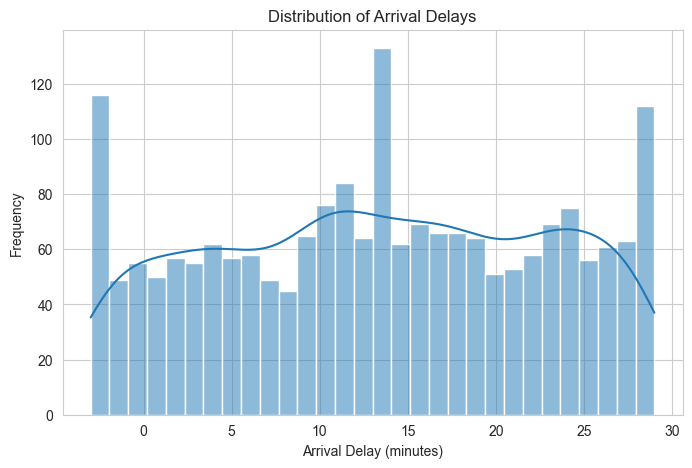

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["actual_arrival_delay_min"],
    bins=30,
    kde=True
)

plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Frequency")

plt.show()

In [5]:
df.groupby("traffic_congestion_index")["actual_arrival_delay_min"].mean().head()

traffic_congestion_index
0    14.894737
1    13.714286
2    13.173913
3    12.913043
4    14.260870
Name: actual_arrival_delay_min, dtype: float64

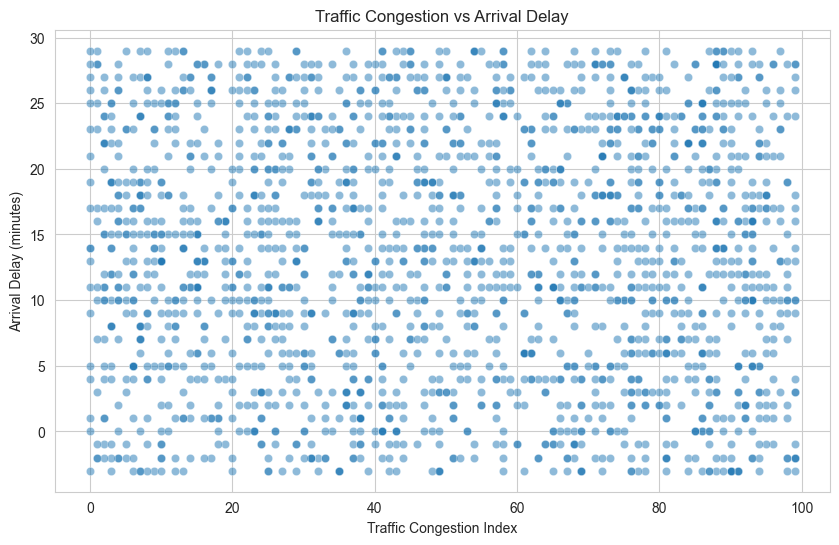

In [6]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="traffic_congestion_index",
    y="actual_arrival_delay_min",
    alpha=0.5
)

plt.title("Traffic Congestion vs Arrival Delay")
plt.xlabel("Traffic Congestion Index")
plt.ylabel("Arrival Delay (minutes)")

plt.show()

In [7]:
df[["traffic_congestion_index", "actual_arrival_delay_min"]].corr()

,traffic_congestion_index,actual_arrival_delay_min
traffic_congestion_index,1.000000,-0.011006
actual_arrival_delay_min,-0.011006,1.000000


In [8]:
df.groupby("weather_condition")["actual_arrival_delay_min"] \
  .mean() \
  .sort_values(ascending=False)

weather_condition
Rain      13.623053
Snow      13.533528
Clear     13.501458
Storm     13.287834
Cloudy    13.073846
Fog       12.879154
Name: actual_arrival_delay_min, dtype: float64

In [9]:
df.groupby("peak_hour")["actual_arrival_delay_min"].mean()

peak_hour
0    13.302198
1    13.360294
Name: actual_arrival_delay_min, dtype: float64

In [10]:
df[["precipitation_mm", "actual_arrival_delay_min"]].corr()

,precipitation_mm,actual_arrival_delay_min
precipitation_mm,1.000000,0.001106
actual_arrival_delay_min,0.001106,1.000000


In [11]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols].corr()["actual_arrival_delay_min"] \
    .sort_values(ascending=False)

actual_arrival_delay_min      1.000000
delayed                       0.763662
event_attendance_est          0.037266
holiday                       0.033584
peak_hour                     0.002784
precipitation_mm              0.001106
actual_departure_delay_min   -0.007161
wind_speed_kmh               -0.007649
weekday                      -0.007785
traffic_congestion_index     -0.011006
humidity_percent             -0.027705
temperature_C                -0.039944
Name: actual_arrival_delay_min, dtype: float64

In [12]:
df.groupby("transport_type")["actual_arrival_delay_min"] \
  .agg(["mean", "median", "count"]) \
  .sort_values("mean", ascending=False)

,mean,median,count
transport_type,,,
Train,13.547667,13.0,493
Bus,13.540952,14.0,525
Metro,13.213849,13.0,491
Tram,12.953157,13.0,491


In [13]:
df.groupby("event_type")["actual_arrival_delay_min"] \
  .agg(["mean", "median", "count"])

,mean,median,count
event_type,,,
Concert,12.832512,13.0,203
Festival,12.769231,13.0,221
Parade,13.619048,14.0,105
Protest,13.895349,13.0,86
Sports,12.820755,13.0,212


# Key EDA Findings

## Dataset Overview
- The dataset contains 2,000 transport trip records and 24 features covering weather, traffic, events, scheduling, and transport operations.
- Arrival delay ranges from -3 minutes (early arrival) to 29 minutes (late arrival).
- The target variable selected for modeling is `actual_arrival_delay_min`.

## Data Quality
- No duplicate records were identified.
- Missing values exist only in `event_type` (1,173 rows, ~58.6% of the dataset).
- Missing `event_type` values likely represent the absence of a city event and will be treated as `No_Event` during preprocessing.

## Target Variable Analysis
- The arrival delay distribution is relatively uniform across the observed range.
- No significant outliers or extreme delay values were detected.
- The target does not require transformation at this stage.

## Feature Analysis

### Traffic Conditions
- Traffic congestion index showed virtually no linear relationship with arrival delay (correlation ≈ -0.01).
- No clear trend was visible between congestion levels and delay duration.

### Weather Conditions
- Average delays across weather categories were very similar.
- Rain produced the highest average delay (~13.6 min) while fog produced the lowest (~12.9 min).
- The difference between weather categories was less than one minute, suggesting weak predictive separation.

### Peak-Hour Operations
- Peak-hour and non-peak-hour trips exhibited nearly identical average delays.
- Peak-hour status alone does not appear to strongly influence delay duration.

### Transport Modes
- Train and Bus services showed slightly higher average delays than Metro and Tram services.
- Differences between transport types were modest (<1 minute).

### Event Impact
- Protest and Parade events were associated with the highest average delays.
- Festival, Sports, and Concert events showed slightly lower average delays.
- Event-related differences were larger than those observed for weather and transport type, though still relatively small.

## Correlation Analysis
- The `delayed` variable displayed a strong correlation with arrival delay (0.76) but is derived from the target and therefore cannot be used as a predictive feature.
- Most numerical variables exhibited very weak linear correlations with the target (< |0.05|).

## Key Takeaways
- Many individual features show weak standalone relationships with arrival delay.
- Predictive performance will likely depend on combining multiple features rather than relying on any single variable.
- Feature engineering and interaction effects may provide more useful signal than raw features alone.
- The dataset appears to be synthetically generated for machine learning practice rather than representing real-world transit operations.